In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [6]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.3f}")

Train: (7000, 18)
Val: (1500, 18)
Test: (1500, 18)
Train failure rate: 0.034


In [8]:
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")

[LightGBM] [Info] Number of positive: 237, number of negative: 6763
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2293
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1449
           1       0.88      0.88      0.88        51

    accuracy                           0.99      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.99      0.99      0.99      1500

F1 Score: 0.882


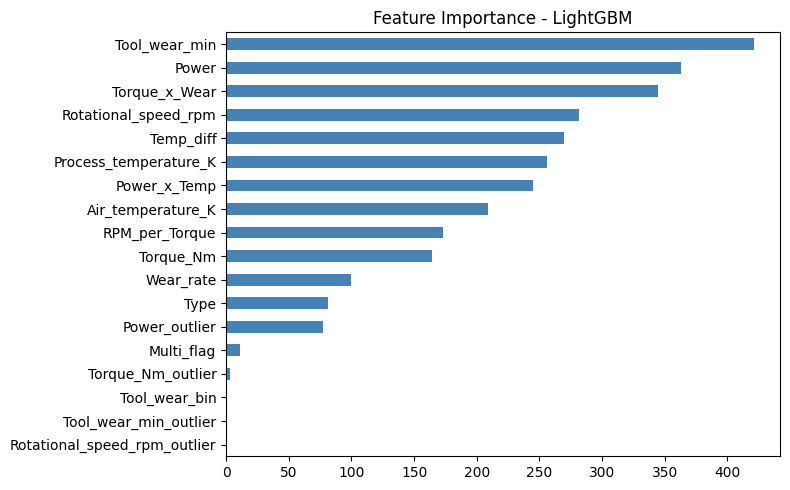

Feature importance saved!


In [9]:
feat_imp = pd.Series(model.feature_importances_, 
                     index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', 
                            figsize=(8,5), 
                            color='steelblue')
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.savefig('../reports/figures/10_feature_importance.png')
plt.show()
print("Feature importance saved!")